### NYC 311 Service Requests — Data Preprocessing

This notebook prepares raw NYC 311 service request data for machine learning modeling.

The objective of the project is to predict whether a complaint will be resolved within one week of submission. To support this goal, the preprocessing workflow performs the following steps:

1. Load and inspect the raw data
2. Remove features that may introduce data leakage
3. Create the modeling target variable
4. Engineer time-based features
5. Clean and standardize geographic information
6. Handle categorical variables and missing values
7. Remove non-predictive identifiers
8. Export the cleaned dataset for feature engineering and modeling

The output of this notebook is a cleaned dataset ready for exploratory analysis.

#### Import libaries
The required Python libraries for data manipulation and preprocessing are imported here.

Key libraries used:

- **pandas / numpy** – data manipulation and transformation
- **datetime** / **time** – handling temporal fields

These tools support efficient cleaning and transformation of NYC 311 service request data.

In [1]:
# Core analysis libraries
import pandas as pd
import numpy as np
import requests
import time
import datetime
from pathlib import Path

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot styling
sns.set()

# Show all columns during EDA
pd.set_option('display.max_columns', None)

In [2]:
# File paths
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
SRC_DIR = PROJECT_ROOT / "src"
DEPLOYMENT_DIR = PROJECT_ROOT / "deployment"

#### Import data
The raw NYC 311 dataset is loaded into a pandas DataFrame.

The dataset contains service request records including:

- complaint metadata
- timestamps
- geographic identifiers
- agency information
- complaint classifications

Initial inspection is performed to confirm that the data loads correctly and to understand the structure of the dataset.

In [3]:
url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json"

limit = 5000
all_data = []
offset = 0

columns = [
    "unique_key",
    "created_date",
    "closed_date",
    "agency",
    "agency_name",
    "complaint_type",
    "descriptor",
    "location_type",
    "incident_zip",
    "borough",
    "bbl",
    "latitude",
    "longitude",
    "status"
]

start_date = (
    datetime.datetime.now(datetime.UTC) - datetime.timedelta(days=30)
).strftime("%Y-%m-%dT%H:%M:%S")

while True:
    params = {
        "$select": ",".join(columns),
        "$limit": limit,
        "$offset": offset,
        "$order": "created_date DESC",
        "$where": f"created_date >= '{start_date}' AND closed_date IS NOT NULL"
    }

    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()

    rows = response.json()

    if not rows:
        break

    all_data.extend(rows)
    print(f"Pulled {len(rows)} rows at offset {offset}")

    offset += limit
    time.sleep(0.2)


Pulled 5000 rows at offset 0
Pulled 5000 rows at offset 5000
Pulled 5000 rows at offset 10000
Pulled 5000 rows at offset 15000
Pulled 5000 rows at offset 20000
Pulled 5000 rows at offset 25000
Pulled 5000 rows at offset 30000
Pulled 5000 rows at offset 35000
Pulled 5000 rows at offset 40000
Pulled 5000 rows at offset 45000
Pulled 5000 rows at offset 50000
Pulled 5000 rows at offset 55000
Pulled 5000 rows at offset 60000
Pulled 5000 rows at offset 65000
Pulled 5000 rows at offset 70000
Pulled 5000 rows at offset 75000
Pulled 5000 rows at offset 80000
Pulled 5000 rows at offset 85000
Pulled 5000 rows at offset 90000
Pulled 5000 rows at offset 95000
Pulled 5000 rows at offset 100000
Pulled 5000 rows at offset 105000
Pulled 5000 rows at offset 110000
Pulled 5000 rows at offset 115000
Pulled 5000 rows at offset 120000
Pulled 5000 rows at offset 125000
Pulled 5000 rows at offset 130000
Pulled 5000 rows at offset 135000
Pulled 5000 rows at offset 140000
Pulled 5000 rows at offset 145000
Pulle

In [4]:
# Save data as parquet file
data = pd.DataFrame(all_data)
data.to_parquet(DATA_DIR / "00_nyc_info_data.parquet", index=False)

#### Details of data
Before preprocessing begins, I examined the structure of the dataset:

- number of observations
- feature data types
- missing values
- potential identifiers or non-predictive fields

Understanding the dataset structure helps guide me preprocessing decisions and identify columns that may require cleaning or transformation.

In [5]:
# Show first five records of data
data.head(5)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,incident_zip,borough,status,latitude,longitude,location_type,bbl
0,68338551,2026-03-16T02:07:42.000,2026-03-16T02:07:42.000,DOT,Department of Transportation,Street Condition,Pothole,11214,BROOKLYN,Closed,NaN,NaN,NaN,NaN
1,68336154,2026-03-16T01:56:08.000,2026-03-16T01:56:08.000,DOT,Department of Transportation,Street Condition,Pothole,11420,QUEENS,Closed,40.67815026036459,-73.83108216039838,NaN,NaN
2,68332725,2026-03-16T01:45:13.000,2026-03-16T02:00:20.000,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,11104,QUEENS,Closed,40.74289748229957,-73.92539941296796,Residential Building/House,4001950050
3,68338535,2026-03-16T01:36:59.000,2026-03-16T02:00:16.000,NYPD,New York City Police Department,Blocked Driveway,Partial Access,11429,QUEENS,Closed,40.71504271880123,-73.73734735839922,Street/Sidewalk,4107670012
4,68339824,2026-03-16T01:32:33.000,2026-03-16T01:59:19.000,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,10462,BRONX,Closed,40.83818203836788,-73.85910315534136,Residential Building/House,2039437501


In [6]:
# Number of rows and columns
data.shape

(272018, 14)

In [7]:
# Number of unique keys
data["unique_key"].drop_duplicates()
data.shape

(272018, 14)

In [8]:
# Data types along with count of missing
types_null_counts = pd.DataFrame()
types_null_counts["Data Type"] = data.dtypes
types_null_counts["Count of Nulls"] = data.isna().sum()
types_null_counts

,Data Type,Count of Nulls
unique_key,object,0
created_date,object,0
closed_date,object,0
agency,object,0
agency_name,object,0
complaint_type,object,0
descriptor,object,0
incident_zip,object,3438
borough,object,0
status,object,0


#### Drop 'status' to avoid leakage
The `status` column is removed prior to modeling.

This variable reflects the final outcome of the complaint resolution process, which occurs after the request has already been handled.

Including this feature would introduce data leakage, allowing the model to indirectly observe the outcome it is trying to predict.

To ensure a realistic predictive modeling scenario, this column is excluded.

In [9]:
data = data.drop(columns=["status"], errors="ignore")
data.columns

Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'incident_zip', 'borough', 'latitude',
       'longitude', 'location_type', 'bbl'],
      dtype='object')

#### Create target based on resolution time
The modeling target is derived from the difference between:

- **created_date**
- **closed_date**

The resolution time is calculated in days, and a binary target variable is created:

- **1 → resolved within 7 days**
- **0 → resolved after 7 days**

This formulation converts the problem into a binary classification task, enabling the use of standard machine learning algorithms.

In [10]:
# Set "created_date" and "closed_date" as datetime
data[["created_date", "closed_date"]] = data[["created_date", "closed_date"]].apply(pd.to_datetime, errors="coerce")

data[["created_date", "closed_date"]].dtypes

created_date    datetime64[ns]
closed_date     datetime64[ns]
dtype: object

In [11]:
# Function for datetime resolution
data["resolution_time_days"] = (data["closed_date"] - data["created_date"]).dt.total_seconds() / 86400

data["resolution_in_wk"] = (data["resolution_time_days"] > 7).astype(int)

data.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,incident_zip,borough,latitude,longitude,location_type,bbl,resolution_time_days,resolution_in_wk
0,68338551,2026-03-16 02:07:42,2026-03-16 02:07:42,DOT,Department of Transportation,Street Condition,Pothole,11214,BROOKLYN,NaN,NaN,NaN,NaN,0.000000,0
1,68336154,2026-03-16 01:56:08,2026-03-16 01:56:08,DOT,Department of Transportation,Street Condition,Pothole,11420,QUEENS,40.67815026036459,-73.83108216039838,NaN,NaN,0.000000,0
2,68332725,2026-03-16 01:45:13,2026-03-16 02:00:20,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,11104,QUEENS,40.74289748229957,-73.92539941296796,Residential Building/House,4001950050,0.010498,0
3,68338535,2026-03-16 01:36:59,2026-03-16 02:00:16,NYPD,New York City Police Department,Blocked Driveway,Partial Access,11429,QUEENS,40.71504271880123,-73.73734735839922,Street/Sidewalk,4107670012,0.016169,0
4,68339824,2026-03-16 01:32:33,2026-03-16 01:59:19,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,10462,BRONX,40.83818203836788,-73.85910315534136,Residential Building/House,2039437501,0.018588,0


In [12]:
# Number of records in each class
data["resolution_in_wk"].value_counts()

resolution_in_wk
0    258992
1     13026
Name: count, dtype: int64

In [13]:
data["resolution_time_days"].isna().sum()

0

#### Time features
Temporal features are extracted from the complaint creation timestamp.

These features may capture patterns in service response times:

- hour of day
- day of week
- month

Time-based patterns can influence service resolution due to factors such as staffing levels, operational schedules, and complaint volume fluctuations.

In [14]:
# Hour, day of week, month of complaint
data = data.dropna(subset=["resolution_time_days"]).copy()

data["complaint_hr"] = data["created_date"].dt.hour
data["complaint_day"] = data["created_date"].dt.dayofweek
data["complaint_month"] = data["created_date"].dt.month

#### Borough & ZIP Code
Geographic identifiers are cleaned and standardized to ensure consistency.

Borough and ZIP code information can influence complaint resolution time due to:

- service workload differences
- agency resource distribution
- neighborhood characteristics

Ensuring valid NYC geographic identifiers improves model reliability.

In [15]:
# Change all ZIP Codes to strings
data["incident_zip"] = data["incident_zip"].astype(str).str.strip()
data["incident_zip"] = data["incident_zip"].str[:5]

In [16]:
# Further standardize ZIP Code format
data["incident_zip"] = data["incident_zip"].replace("nan", np.nan)
data["incident_zip"] = data["incident_zip"].where(
    data["incident_zip"].str.fullmatch(r"\d{5}", na=False),
    np.nan
)

In [18]:
# Official NYC ZIP Code source
nyc_zips = pd.read_csv(DATA_DIR / "sf1p11.csv")
nyc_zips.head()

,Borough,ZIPCODES
0,Manhattan,10001
1,Manhattan,10002
2,Manhattan,10003
3,Manhattan,10004
4,Manhattan,10005


In [19]:
# Reference df cleaned
zip_ref = nyc_zips[["ZIPCODES", "Borough"]].copy()
zip_ref.columns = ["incident_zip", "borough_official"]

zip_ref["incident_zip"] = zip_ref["incident_zip"].astype(str).str.strip().str[:5]

zip_ref["borough_official"] = (
    zip_ref["borough_official"]
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [20]:
# Standardize borough in 311 data before comparison
data["borough"] = (
    data["borough"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .replace("unspecified", np.nan)
    .replace("nan", np.nan)
)

In [21]:
# Keep only NYC ZIP Codes
data = data[data["incident_zip"].isin(zip_ref["incident_zip"])].copy()

In [22]:
# Merge official borough
data = data.merge(
    zip_ref,
    on="incident_zip",
    how="left"
)

In [23]:
# Compare boroughs
borough_mismatch = data[
    data["borough"].notna() &
    (data["borough"] != data["borough_official"])
]
borough_mismatch.shape

(3422, 19)

In [24]:
# Set borough based in '311' set based on NYC official borough
data["borough"] = data["borough_official"]
data = data.drop(columns=["borough_official"])

In [25]:
# Count of boroughs
data["borough"].value_counts(dropna=False)

borough
brooklyn         80722
queens           68633
bronx            52940
manhattan        47583
staten_island    19743
Name: count, dtype: int64

In [26]:
# Reset index as values have been removed
data = data.reset_index(drop=True)

#### Latitude & Longitude
Latitude and longitude values are retained as location features.

These coordinates allow spatial patterns in service response to be captured by the model and may be used later for:

- spatial feature engineering
- proximity calculations
- geographic visualization in dashboards

In [27]:
# Convert coordinates to numeric
data["latitude"] = pd.to_numeric(data["latitude"], errors="coerce")
data["longitude"] = pd.to_numeric(data["longitude"], errors="coerce")

In [28]:
# Describe latitude
data["latitude"].describe()

count    263110.000000
mean         40.729417
std           0.090275
min          40.498924
25%          40.662189
50%          40.722047
75%          40.813073
max          40.912869
Name: latitude, dtype: float64

In [29]:
# Missing values
data["latitude"].isna().sum()

6511

In [30]:
# Describe longitude
data["longitude"].describe()

count    263110.000000
mean        -73.926997
std           0.085193
min         -74.252448
25%         -73.971376
50%         -73.924901
75%         -73.874819
max         -73.700384
Name: longitude, dtype: float64

In [31]:
# Missing values
data["longitude"].isna().sum()

6511

In [32]:
# Check if the same rows are missing both
missing_long_lat = data[(data["latitude"].isna()) & (data["longitude"].isna())]
missing_long_lat.shape

(6511, 18)

In [33]:
# Drop columns where longitude and latitude are missing
data = data.dropna(subset=["longitude", "latitude"]).copy()

In [34]:
# Check counts after dropping
data.shape

(263110, 18)

#### Complaint Type
Complaint type is one of the most important predictors in the dataset.

Different complaint categories (e.g., noise complaints, sanitation issues, street conditions) may have  different resolution timelines depending on the responsible agency and operational complexity.

This feature is preserved as a categorical predictor for the model.

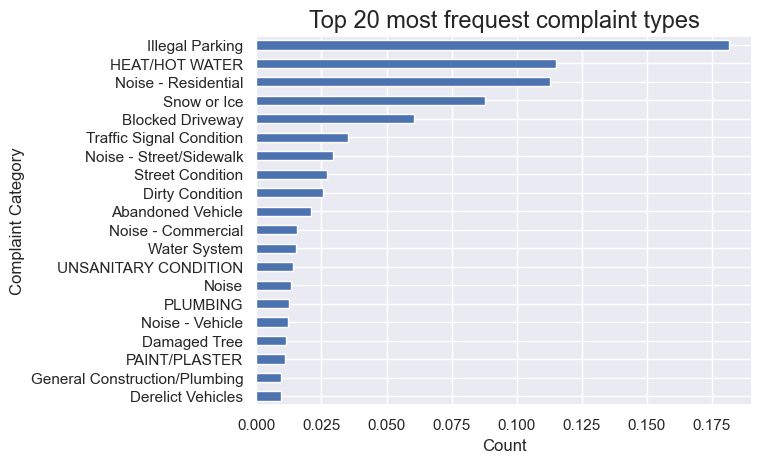

In [35]:
# Top 20 most types of complaints
data["complaint_type"].value_counts(normalize=True).head(20).sort_values().plot.barh()
plt.xlabel("Count")
plt.ylabel("Complaint Category")
plt.title("Top 20 most frequest complaint types", fontsize=17)
plt.show()

In [36]:
# Number of unique complaint types
data["complaint_type"].nunique()

139

In [37]:
# Check for missingness
data["complaint_type"].isna().sum()

0

#### Descriptor
The descriptor field provides more detailed classification within each complaint type.

For example, a noise complaint may have descriptors indicating:

- loud music
- blocked hydrant
- no access

These finer-grained distinctions may help the model capture variation in expected resolution times.

In [38]:
# Number of unique descriptions
data["descriptor"].nunique()

644

In [39]:
data["descriptor"].isna().sum()

0

In [40]:
# Top 15 descriptors
data["descriptor"].value_counts().head(15)

descriptor
Loud Music/Party                 22843
ENTIRE BUILDING                  18987
Blocked Hydrant                  13992
Banging/Pounding                 13399
Snow Tracking                    12527
No Access                        12377
APARTMENT ONLY                   11342
Posted Parking Sign Violation    11324
Sidewalk                          9241
Blocked Sidewalk                  6605
Controller                        6497
Trash                             5756
With License Plate                5480
Loud Talking                      5073
Pothole                           4227
Name: count, dtype: int64

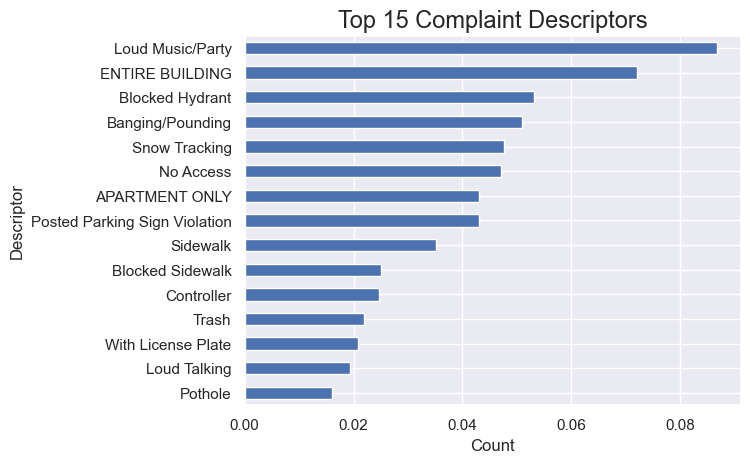

In [41]:
data["descriptor"].value_counts(normalize=True).head(15).sort_values().plot.barh()
plt.xlabel("Count")
plt.ylabel("Descriptor")
plt.title("Top 15 Complaint Descriptors", fontsize=17)
plt.show()

#### Agency
Each complaint is routed to a responsible city agency.

Different agencies operate under different workloads, response protocols, and staffing levels, which may influence resolution time.

This feature is therefore retained as a categorical predictor.

In [42]:
# Count of each agency with which the complaint was routed
data["agency"].value_counts(dropna=False)

agency
NYPD     120836
HPD       48850
DSNY      41659
DOT       20268
DEP       11733
DOB        8370
DPR        5377
DOHMH      2671
DHS        1977
DCWP        662
TLC         517
DOE         178
OTI          12
Name: count, dtype: int64

In [43]:
# Number of unique departments listed
data["agency"].nunique()

13

#### Location Type
The location type describes the setting of the complaint, such as:

- residential building
- street or sidewalk
- commercial property

These contextual details may influence the complexity of resolving a request and are therefore preserved as a modeling feature.

In [44]:
data["location_type"].value_counts(dropna=False)

location_type
Street/Sidewalk               84390
RESIDENTIAL BUILDING          48850
NaN                           35003
Residential Building/House    31919
Street                        29738
                              ...  
Cafeteria - Public School         1
Hospital                          1
Soup Kitchen                      1
Inside                            1
Overpass                          1
Name: count, Length: 84, dtype: int64

In [45]:
data["location_type"].nunique()

83

#### Handle categorical columns' missingness
Missing values in categorical variables are addressed prior to modeling.

Rather than dropping observations, missing values are filled with an **"Unknown" or equivalent category**, allowing the model to retain all available data while still capturing potential patterns associated with missing information.

In [46]:
categorical_cols = [
    "complaint_type",
    "descriptor",
    "location_type",
    "borough",
    "incident_zip"
]

for col in categorical_cols:
    data[col] = data[col].fillna("unknown")

#### Drop columns not needed for modeling
Certain columns are removed because they do not provide predictive value or serve only as identifiers.

Removing these features ensures the model is trained only on information that would be available when making real-time predictions.

In [47]:
data = data.drop(columns=["closed_date", "agency_name", "created_date", "bbl"], errors="ignore")

#### Export preprocessed data
The final cleaned dataset is exported for use in downstream notebooks.

This dataset serves as the input for:

- feature engineering
- model training
- model evaluation

Separating preprocessing and modeling steps helps maintain a clear and reproducible machine learning workflow.

In [48]:
# Final check of data
data.isna().sum().sort_values(ascending=False)
data.info()
data.shape

<class 'pandas.core.frame.DataFrame'>
Index: 263110 entries, 1 to 269620
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   unique_key            263110 non-null  object 
 1   agency                263110 non-null  object 
 2   complaint_type        263110 non-null  object 
 3   descriptor            263110 non-null  object 
 4   incident_zip          263110 non-null  object 
 5   borough               263110 non-null  object 
 6   latitude              263110 non-null  float64
 7   longitude             263110 non-null  float64
 8   location_type         263110 non-null  object 
 9   resolution_time_days  263110 non-null  float64
 10  resolution_in_wk      263110 non-null  int32  
 11  complaint_hr          263110 non-null  int32  
 12  complaint_day         263110 non-null  int32  
 13  complaint_month       263110 non-null  int32  
dtypes: float64(3), int32(4), object(7)
memory usage: 26.1+ MB

(263110, 14)

In [49]:
# Export to parquet file
data.to_parquet(DATA_DIR / "01_nyc_info_preprocessing.parquet", index=False)